In [75]:
# imports and settings

# !pip install crepe
import os
import pandas as pd
import warnings
from scipy.io import wavfile
import crepe
from tqdm import tqdm
import matplotlib.pyplot as plt
import crepe
import time as t
from scipy.io import wavfile
import numpy as np

# Set the default style to light mode
plt.style.use('default')

# Feature Engineering
This section is not necessary and was used to map out the features and plot the data. All the functions defined in this section are defined again in the next section.
<!-- Simplify the data into fundamental features -->

### Feature 1: Core Frequency

In [3]:
def get_core_frequency(file_path):
    sr, audio = wavfile.read(file_path)
    time, frequency, confidence, activation = crepe.predict(audio, sr, viterbi=True)
    return frequency, time

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


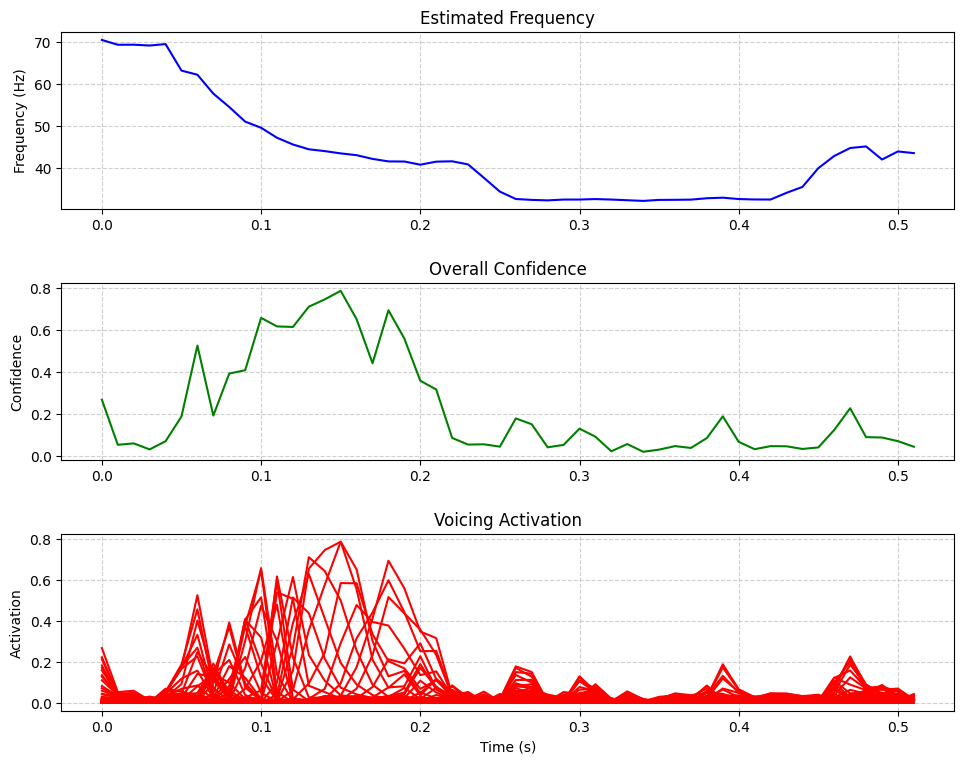

The core frequency is 43.06632351827611 Hz


In [19]:
# Example
sr, audio = wavfile.read("SortedSamples/kicks/ah_kick_gust.wav")
time, frequency, confidence, activation = crepe.predict(audio, sr, viterbi=True)

plt.figure(figsize=(10, 8))
plt.subplot(3, 1, 1)
plt.plot(time, frequency, color='b', linewidth=1.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylabel('Frequency (Hz)')
plt.title('Estimated Frequency')
plt.tight_layout(pad=2.0)

plt.subplot(3, 1, 2)
plt.plot(time, confidence, color='g', linewidth=1.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylabel('Confidence')
plt.title('Overall Confidence')
plt.tight_layout(pad=2.0)

plt.subplot(3, 1, 3)
plt.plot(time, activation, color='r', linewidth=1.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylabel('Activation')
plt.xlabel('Time (s)')
plt.title('Voicing Activation')
plt.tight_layout(pad=2.0)
# plt.gca().set_prop_cycle(color=plt.cm.Reds(np.linspace(0.3, 1, len(time))))

plt.show()

print(f'The core frequency is {frequency.mean()} Hz')

# # Plot
# plt.plot(time, frequency)
# plt.xlabel('Time (s)')
# plt.ylabel('Frequency (Hz)')
# plt.show()

### Feature 2: Max Amplitude

In [20]:
def get_max_amplitude(file_path):
    sr, audio = wavfile.read(file_path)
    return np.max(audio), audio

The max amplitude is 1793682176


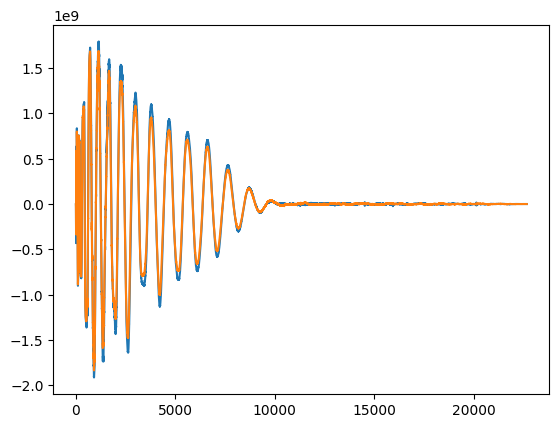

In [21]:
# Example
max_amplitude, audio = get_max_amplitude('SortedSamples/kicks/ah_kick_gust.wav')

print(f'The max amplitude is {max_amplitude}')

# plot the amplitude
plt.plot(audio)

# show the max amplitude on the plot
# plt.text(0, max_amplitude, f'Max amplitude: {max_amplitude}')
plt.show()

### Feature 3: Average Activation

In [22]:
def get_activation(file_path):
    sr, audio = wavfile.read(file_path)
    time, frequency, confidence, activation = crepe.predict(audio, sr, viterbi=True)
    return time, activation

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


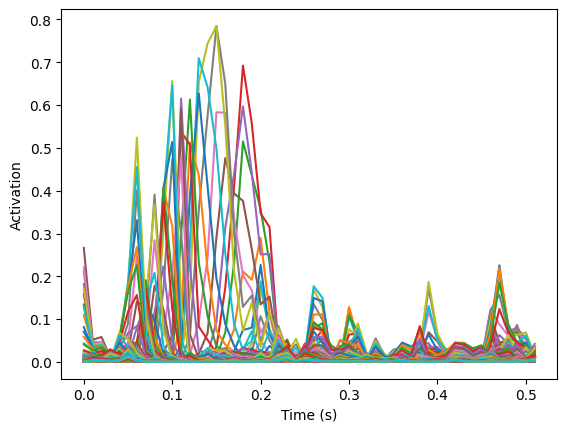

The average activation is 0.006699345540255308


In [23]:
# Example
get_activation('SortedSamples/kicks/ah_kick_gust.wav')

# plot activation
plt.plot(time, activation)
plt.xlabel('Time (s)')
plt.ylabel('Activation')
plt.show()

# avergae the activation
print(f'The average activation is {activation.mean()}')

### Feature 4: Duration

In [24]:
def get_sample_duration(file_path):
    sr, audio = wavfile.read(file_path)
    return len(audio) / sr

In [25]:
# Example
get_sample_duration('SortedSamples/kicks/ah_kick_gust.wav')

print(f'The duration of the sample is {get_sample_duration("SortedSamples/kicks/ah_kick_gust.wav")} seconds')

The duration of the sample is 0.513968253968254 seconds


In [12]:
# Create a dataframe with each of these features given a sample
def get_sample_features(file_path):
    time, activation = get_activation(file_path)
    return {
        'core_frequency': get_core_frequency(file_path),
        'max_amplitude': get_max_amplitude(file_path)[0], 
        'average_activation': activation.mean(),
        'duration': get_sample_duration(file_path)
    }

# # Example
get_sample_features('SortedSamples/kicks/ah_kick_gust.wav')

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 239ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step


{'core_frequency': (array([70.58818592, 69.4339741 , 69.45026503, 69.25134458, 69.59422167,
         63.25341558, 62.27123619, 57.7558564 , 54.55819835, 51.06148992,
         49.58965866, 47.20183935, 45.59061378, 44.44493958, 44.00854724,
         43.46474102, 43.03548415, 42.14803124, 41.54763305, 41.51859214,
         40.76544499, 41.4883296 , 41.57410242, 40.82990467, 37.611613  ,
         34.3225207 , 32.55871013, 32.34729129, 32.22989838, 32.42451669,
         32.43226205, 32.54418399, 32.42950435, 32.26294296, 32.10694112,
         32.34299618, 32.36549173, 32.41184494, 32.738127  , 32.87326222,
         32.55281052, 32.44784409, 32.43440732, 34.03106639, 35.44410504,
         39.92921419, 42.84515451, 44.75204461, 45.12753832, 41.99786746,
         43.92794938, 43.53061403]),
  array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
         0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
         0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29

# Process Data
The following cell converts various features from each audio sample in a directory labeled "Sorted Samples". It saves the data into a csv called sample_features.csv, which contains the features used for model training and inference.

In [26]:
warnings.filterwarnings('ignore')

def get_core_frequency(file_path):
    sr, audio = wavfile.read(file_path)
    time, frequency, confidence, activation = crepe.predict(audio, sr, viterbi=True)
    return frequency.mean()

def get_max_amplitude(file_path):
    sr, audio = wavfile.read(file_path)
    return np.max(audio)

def get_activation(file_path):
    sr, audio = wavfile.read(file_path)
    time, frequency, confidence, activation = crepe.predict(audio, sr, viterbi=True)
    return activation

def get_sample_duration(file_path):
    sr, audio = wavfile.read(file_path)
    return len(audio) / sr

def get_sample_features(file_path):
    return {
        'core_frequency': get_core_frequency(file_path),
        'max_amplitude': get_max_amplitude(file_path),
        'average_activation': get_activation(file_path).mean(),
        'duration': get_sample_duration(file_path)
    }

def process_samples_to_csv():
    samples = []
    # types = ['claps', 'cymbals', 'hihats', 'kicks', 'percs', 'rides', 'snares', 'toms']
    types = ['new kicks', 'new snares', 'new rides', 'new toms']
    for category in types:
        for root, dirs, files in os.walk(f'SortedSamples/{category}'):
            for file in tqdm(files, desc=f"Processing {os.path.basename(root)}", unit="file"):
                if file.endswith('.wav'):
                    try:
                        features = get_sample_features(os.path.join(root, file))
                        features['label'] = os.path.basename(root)
                        samples.append(features)

                        # Convert to DataFrame and save after each file
                        df = pd.DataFrame(samples)
                        df.to_csv(f'sample_features - {category}.csv', index=False)
                    except Exception as e:
                        print(f"Error processing {file}: {e}")
    return samples

# samples = process_samples_to_csv()

# df = pd.DataFrame(samples)
# df.head()

Combines generated dataframes into one main csv

In [15]:
def merge_dataframes():
    orig_data = pd.read_csv('sample_features.csv')
    new_kicks = pd.read_csv('sample_features - new kicks.csv')
    new_snares = pd.read_csv('sample_features - new snares.csv')
    new_rides = pd.read_csv('sample_features - new rides.csv')
    new_toms = pd.read_csv('sample_features - new toms.csv')

    dfs_to_merge = [orig_data, new_kicks, new_rides, new_snares, new_toms]

    new_data = pd.concat(dfs_to_merge)

    # Replace 'new' labels with their base labels
    label_mapping = {
        'new kicks': 'kick',
        'new snares': 'snare', 
        'new rides': 'ride',
        'new toms': 'tom'
    }

    new_data['label'] = new_data['label'].replace(label_mapping)

,core_frequency,max_amplitude,average_activation,duration,label
0,670.382749,3.276700e+04,0.008465,0.093208,clap
1,540.935642,9.125246e-01,0.006048,0.418027,clap
2,625.533177,7.353753e-01,0.006684,0.211587,clap
3,649.487341,9.999999e-01,0.008569,0.307778,clap
4,701.177557,1.000000e+00,0.008139,0.283741,clap
...,...,...,...,...,...
111,188.608389,2.063979e+09,0.009040,0.261224,new toms
112,75.648199,1.853044e+09,0.010361,1.091338,new toms
113,178.782027,1.585885e+09,0.009104,0.392925,new toms
114,238.035837,2.122901e+09,0.009068,0.481814,new toms


## Data Cleaning

### Filter Dataset

In [44]:
### Filter Dataset
data = pd.read_csv('Sample Features/sample_features.csv')

def filter_data(data):
    # Remove duration outliers
    data = data[data['duration'] < 10]
    
    # Additional duration filters for specific instruments
    mask = (
        ((data['label'] == 'hat') & (data['duration'] < 5)) |
        ((data['label'] == 'kick') & (data['duration'] < 5)) |
        ((data['label'] == 'snare') & (data['duration'] < 5)) |
        ((data['label'].isin(['perc', 'ride', 'clap', 'tom']) == False))
    )
    data = data[mask] 
    
    # Remove unwanted labels
    data = data[data['label'] != 'perc']
    data = data[data['label'] != 'ride'] 
    data = data[data['label'] != 'clap']
    data = data[data['label'] != 'tom']

    # merge the rides and cymbals into rides
    data['label'] = data['label'].replace('rides', 'ride')
    data['label'] = data['label'].replace('cymbal', 'ride')

    data["label"].value_counts()
    return data

data = filter_data(data)
# data.value_counts('label')

### Balance Dataset

In [45]:
### Balance Dataset
def balance_dataset(data):
    # Check for any label imbalances
    class_distribution = data['label'].value_counts()

    # Calculate the minimum class count for balancing
    min_class_count = class_distribution.min()

    # Balance the dataset by undersampling
    balanced_data = data.groupby('label').apply(lambda x: x.sample(n=min_class_count, random_state=42)).reset_index(drop=True)

    # Check the new class distribution
    balanced_data['label'].value_counts()

    data = balanced_data
    
    # Save balanced dataset to CSV
    balanced_data.to_csv('sample_features_balanced.csv', index=False)

    return data

data = balance_dataset(data)
# data["label"].value_counts()

Initially, the data was heavily unweighted:

    label
    kick     471
    snare    467
    tom      250
    clap     138
    ride     120
    hat      111

After filtering, the data looked like this: 

    label
    kick     467
    snare    461
    ride     111
    hat      103

After balancing the dataset, the data looks like this: 

    label
    hat      103
    kick     103
    ride     103
    snare    103


# Visualize Data

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = pd.read_csv('sample_features_balanced.csv')
# Plot feature distributions to understand their characteristics
plt.figure(figsize=(14, 10))
for i, column in enumerate(data.columns[:-1], 1):  # Exclude label column
    plt.subplot(2, 2, i)
    sns.histplot(data, x=column, hue='label', kde=True, palette='Set2')
    plt.title(f'Distribution of {column}')

# Display correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(data.drop('label', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

***Insights:***

Insights from the Distributions:

1.	Core Frequency:
    * Most labels, especially “hat,” cluster around low values of core frequency.
    *	The distribution for “ride” and “kick” is more spread out, suggesting these sounds have a wider range of core frequencies.
2.	Max Amplitude:
    *	The “hat” label shows a strong clustering near the lower end of max amplitude values.
    *	“Snare” and “kick” have higher amplitudes, with the distributions being more spread out towards larger values.
3.	Average Activation:
    *	“Hat” and “kick” tend to have distinct activation profiles.
    *	Overlap between “snare” and “ride” exists, which might make distinguishing between these labels harder based on this feature.
4.	Duration:
    *	Most sounds have short durations, with the “snare” category showing slightly longer durations on average compared to others.
    *	The “ride” and “kick” labels are sparse for longer durations.

Correlation Insights:
1. Strongest Negative Correlation:
    *	core_frequency and average_activation are negatively correlated (-0.59). Higher core frequencies tend to have lower average activation levels.
2. Weak or No Correlation:
    *	Most other features show weak correlations with each other, suggesting independent characteristics.

### PCA

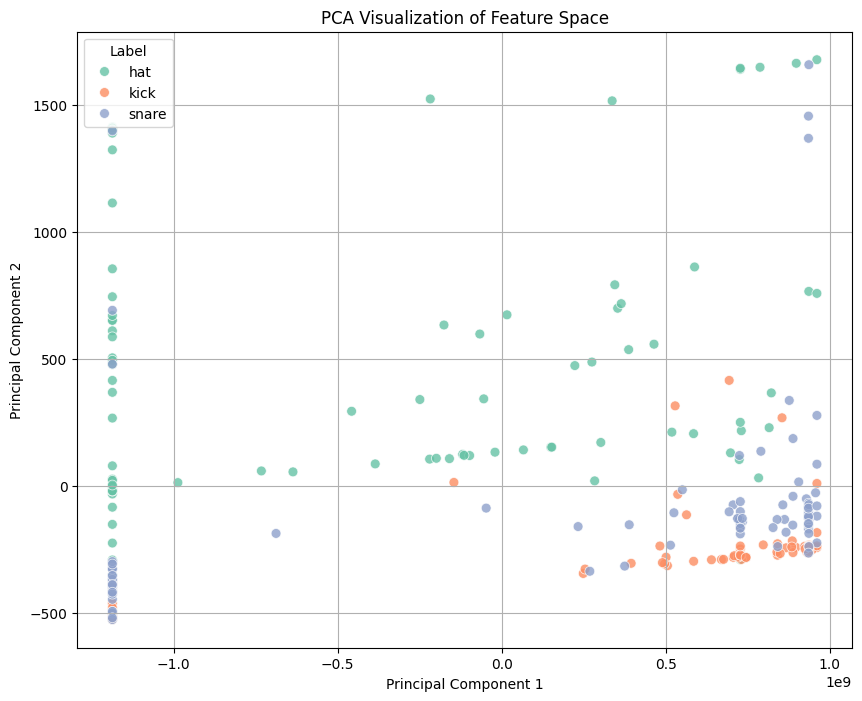

In [33]:
# PCA
from sklearn.decomposition import PCA
import numpy as np

# Apply PCA to reduce features to 2 dimensions for visualization
pca = PCA(n_components=2)
data_features = data.iloc[:, :-1]  # Exclude the label column
data_pca = pca.fit_transform(data_features)

# Create a DataFrame for PCA results and add labels
pca_df = pd.DataFrame(data_pca, columns=['PCA1', 'PCA2'])
pca_df['label'] = data['label']

# Plot the PCA results for better visualization of class separability
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='label', palette="Set2", s=50, alpha=0.8)
plt.title("PCA Visualization of Feature Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Label')
plt.grid(True)
plt.show()

# Analyze various models

In [74]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Prepare features and labels
X = data.drop('label', axis=1)
y = data['label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models
models = {
    'Gradient Boosting': GradientBoostingClassifier(),
    'k-Nearest Neighbors': KNeighborsClassifier(), 
    'Support Vector Machine': SVC(),
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression': LogisticRegression()
}

# Train and evaluate each model
results = []
for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Convert report to dataframe and add model name column
    report_df = pd.DataFrame(report).transpose()
    report_df['model'] = model_name
    results.append(report_df[['precision', 'model']])

# Combine all results and pivot
final_df = pd.concat(results)
final_df = final_df.pivot(columns='model', values='precision')
display(final_df)


model,Gradient Boosting,Logistic Regression,Random Forest,Support Vector Machine,k-Nearest Neighbors
accuracy,0.843373,0.819277,0.879518,0.807229,0.759036
hat,1.000000,0.960000,1.000000,1.000000,0.923077
kick,0.772727,0.800000,0.809524,0.736842,0.615385
macro avg,0.847222,0.809748,0.876984,0.802033,0.757479
ride,0.888889,0.764706,0.888889,0.789474,0.769231
snare,0.727273,0.714286,0.809524,0.681818,0.722222
weighted avg,0.859742,0.824453,0.889080,0.821179,0.777160


## Notes:
* removing percs improves the overall ccuracy by about 5-6%
* with a lowerer of labels (kicks, snares, hats), as well as filtering time < 5, the accuracy for gradient boosting and random forest sits around 87%
* Removing rides percs improves the accruacy (up to 87%)
    * consider adding more rides and percs to the dataset
    * removing the time column makes the average accuracy across all models to around 70% (if rides and percs are removed)
* Balancing the dataset to 111 samples per feature decreases overall accuracy. Especially kick down to around 50%
    * removing clap from the balanced dataset improves accuracy of kick from 50% -> 74% for Gradient Boosting.
        * hat decreases slightly (100-95%)
* Overlapping distributions in some features (average_activation for snare/ride) highlight why the use of non-linear classifiers(SVM, decision trees...) performs well

# Things to try:
* Combine (by creating interation terms) core_frequency and average activation


In [51]:
# data

,core_frequency,max_amplitude,average_activation,duration
0,1.167454,-1.264499,-1.962023,-0.700665
1,0.141086,-0.124519,-1.909075,-0.718439
2,0.143295,0.956711,-1.459990,-0.694251
3,0.153461,-0.168883,-1.053245,-0.363315
4,2.931276,-1.264533,-1.887240,-0.709094
...,...,...,...,...
407,-0.296864,1.056697,1.220273,0.619370
408,-0.570784,1.089698,1.010732,-0.643367
409,-0.577704,-1.264501,0.068194,-0.524374
410,-0.571704,1.091015,-0.584697,-0.620885


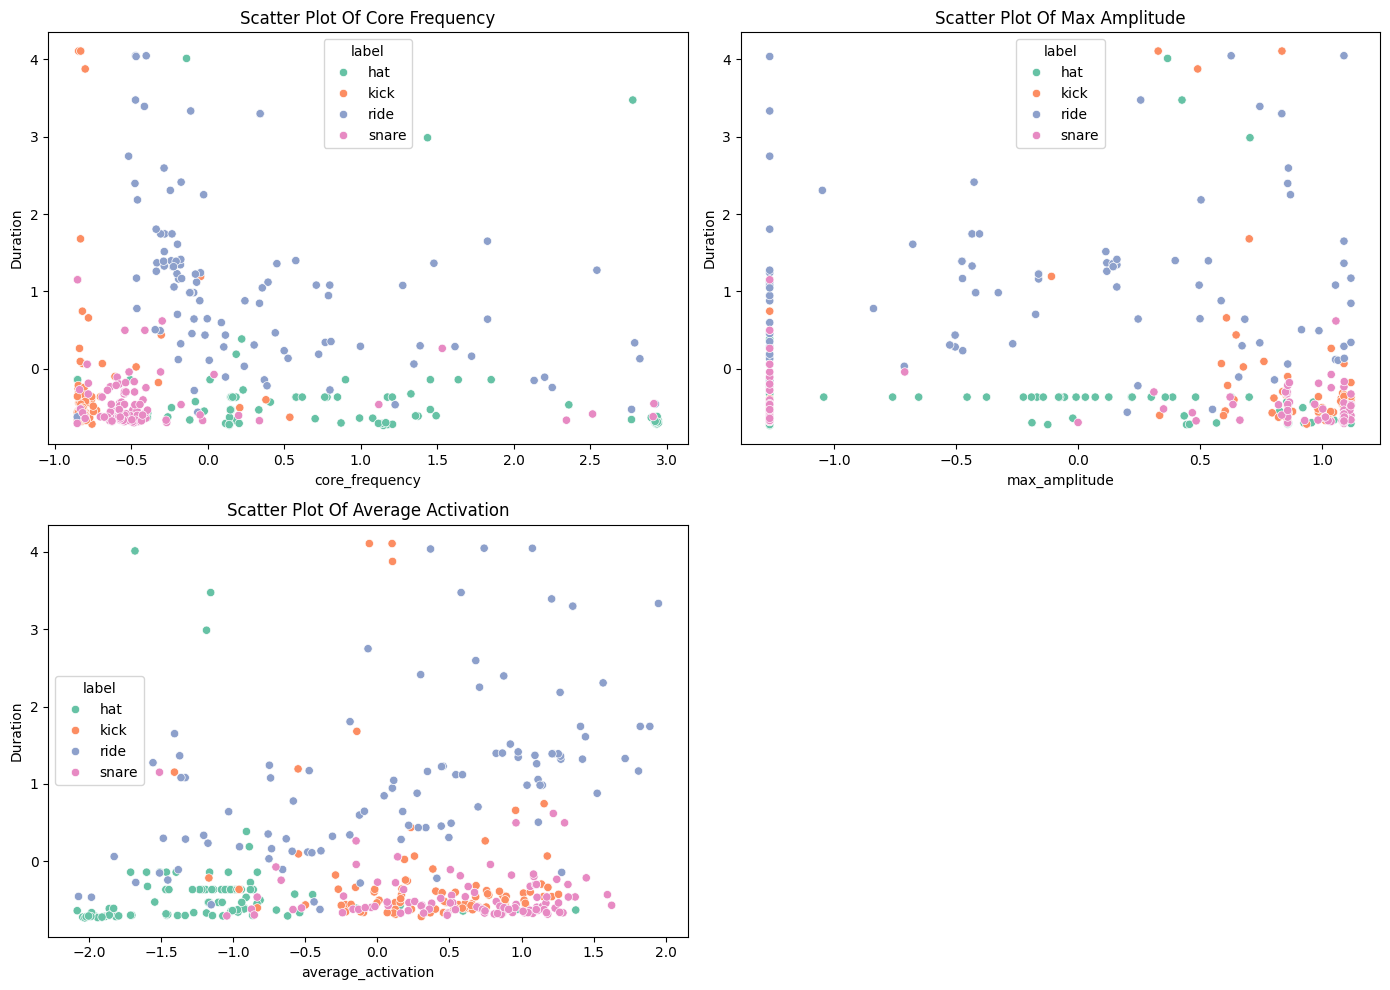

In [72]:
# Visualize the data
# standardize the data
scaler = StandardScaler()
X = data.drop('label', axis=1)  # Ensure X is defined correctly
X_scaled = scaler.fit_transform(X)

# standardize each feature
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# plot each feature in a scatter plot
plt.figure(figsize=(14, 10))
for i, column in enumerate(X_scaled.columns[:-1], 1):  # Exclude the last column (duration)
    plt.subplot(2, 2, i)
    sns.scatterplot(data=pd.concat([X_scaled, data['label']], axis=1), x=column, y='duration', hue='label', palette='Set2')
    plt.title(f'Scatter Plot Of {column.replace("_", " ").title()}')
    plt.xlabel(column)
    plt.ylabel('Duration')

plt.tight_layout()
plt.show()